In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataset=pd.read_csv('Algerian_forest_fires_dataset_UPDATE.csv', header=0)

In [3]:
dataset.head()

,Unnamed: 0,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237 entries, 0 to 236
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   237 non-null    int64  
 1   day          237 non-null    int64  
 2   month        237 non-null    int64  
 3   year         237 non-null    int64  
 4   Temperature  237 non-null    int64  
 5   RH           237 non-null    int64  
 6   Ws           237 non-null    int64  
 7   Rain         237 non-null    float64
 8   FFMC         237 non-null    float64
 9   DMC          237 non-null    float64
 10  DC           237 non-null    float64
 11  ISI          237 non-null    float64
 12  BUI          237 non-null    float64
 13  FWI          237 non-null    float64
 14  Classes      237 non-null    object 
 15  Region       237 non-null    int64  
dtypes: float64(7), int64(8), object(1)
memory usage: 29.8+ KB


## data cleaning

In [5]:
dataset.drop(['Unnamed: 0'], axis=1, inplace=True)

In [6]:
#checking the missing values
dataset[dataset.isnull().any(axis=1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region


creating a new column which will store the region of each record

In [7]:
dataset.loc[:122,"Region"]=0
dataset.loc[122:,"Region"]=1

In [8]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237 entries, 0 to 236
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          237 non-null    int64  
 1   month        237 non-null    int64  
 2   year         237 non-null    int64  
 3   Temperature  237 non-null    int64  
 4   RH           237 non-null    int64  
 5   Ws           237 non-null    int64  
 6   Rain         237 non-null    float64
 7   FFMC         237 non-null    float64
 8   DMC          237 non-null    float64
 9   DC           237 non-null    float64
 10  ISI          237 non-null    float64
 11  BUI          237 non-null    float64
 12  FWI          237 non-null    float64
 13  Classes      237 non-null    object 
 14  Region       237 non-null    int64  
dtypes: float64(7), int64(7), object(1)
memory usage: 27.9+ KB


In [9]:
dataset[['Region']]=dataset[['Region']].astype('int')

In [10]:
#removing the missing values
dataset=dataset.dropna().reset_index(drop=True)

In [11]:
dataset.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [12]:
dataset.isnull().sum()

day            0
month          0
year           0
Temperature    0
RH             0
Ws             0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
Region         0
dtype: int64

In [13]:
dataset.iloc[[122]]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,7,6,2012,35,44,17,0.2,85.6,9.9,28.9,5.4,10.7,6.0,fire,1


In [14]:
dataset=dataset.drop(122).reset_index(drop=True)

In [15]:
dataset.iloc[[122]]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,8,6,2012,28,51,17,1.3,71.4,7.7,7.4,1.5,7.3,0.8,not fire,1


In [16]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236 entries, 0 to 235
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          236 non-null    int64  
 1   month        236 non-null    int64  
 2   year         236 non-null    int64  
 3   Temperature  236 non-null    int64  
 4   RH           236 non-null    int64  
 5   Ws           236 non-null    int64  
 6   Rain         236 non-null    float64
 7   FFMC         236 non-null    float64
 8   DMC          236 non-null    float64
 9   DC           236 non-null    float64
 10  ISI          236 non-null    float64
 11  BUI          236 non-null    float64
 12  FWI          236 non-null    float64
 13  Classes      236 non-null    object 
 14  Region       236 non-null    int64  
dtypes: float64(7), int64(7), object(1)
memory usage: 27.8+ KB


In [17]:
#fix spaces in column names
dataset.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [18]:
dataset.columns = dataset.columns.str.strip()

In [19]:
dataset.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [20]:
## changing the required columns  as integer
dataset[['month', 'day', 'year', 'Temperature', 'RH', 'Ws']]=dataset[['month', 'day', 'year', 'Temperature', 'RH', 'Ws']].astype('int')

In [21]:
## changing the other columns to float data type
objects = [features for features in dataset.columns if dataset[features].dtype == 'O']

In [22]:
for i in objects:
    if i != 'Classes':
        dataset[i]=dataset[i].astype('float')

In [23]:
dataset.to_csv('Algerian_forest_fires_dataset_UPDATE.csv')

## Exploratory data analysis

In [24]:
#drop day, month, year columns as they are not required for the model
df_copy=dataset.drop(['day', 'month', 'year'], axis=1)

In [25]:
df_copy.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [26]:
#encoding the categories in classes
df_copy['Classes']=np.where(df_copy['Classes'].str.contains('not fire'), 0, 1)

In [27]:
df_copy.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [28]:
df_copy.tail()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
231,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,1,1
232,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0.0,0,1
233,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,0,1
234,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,0,1
235,24,64,15,0.2,67.3,3.8,16.5,1.2,4.8,0.5,0,1


In [29]:
df_copy['Classes'].value_counts()

Classes
1    135
0    101
Name: count, dtype: int64

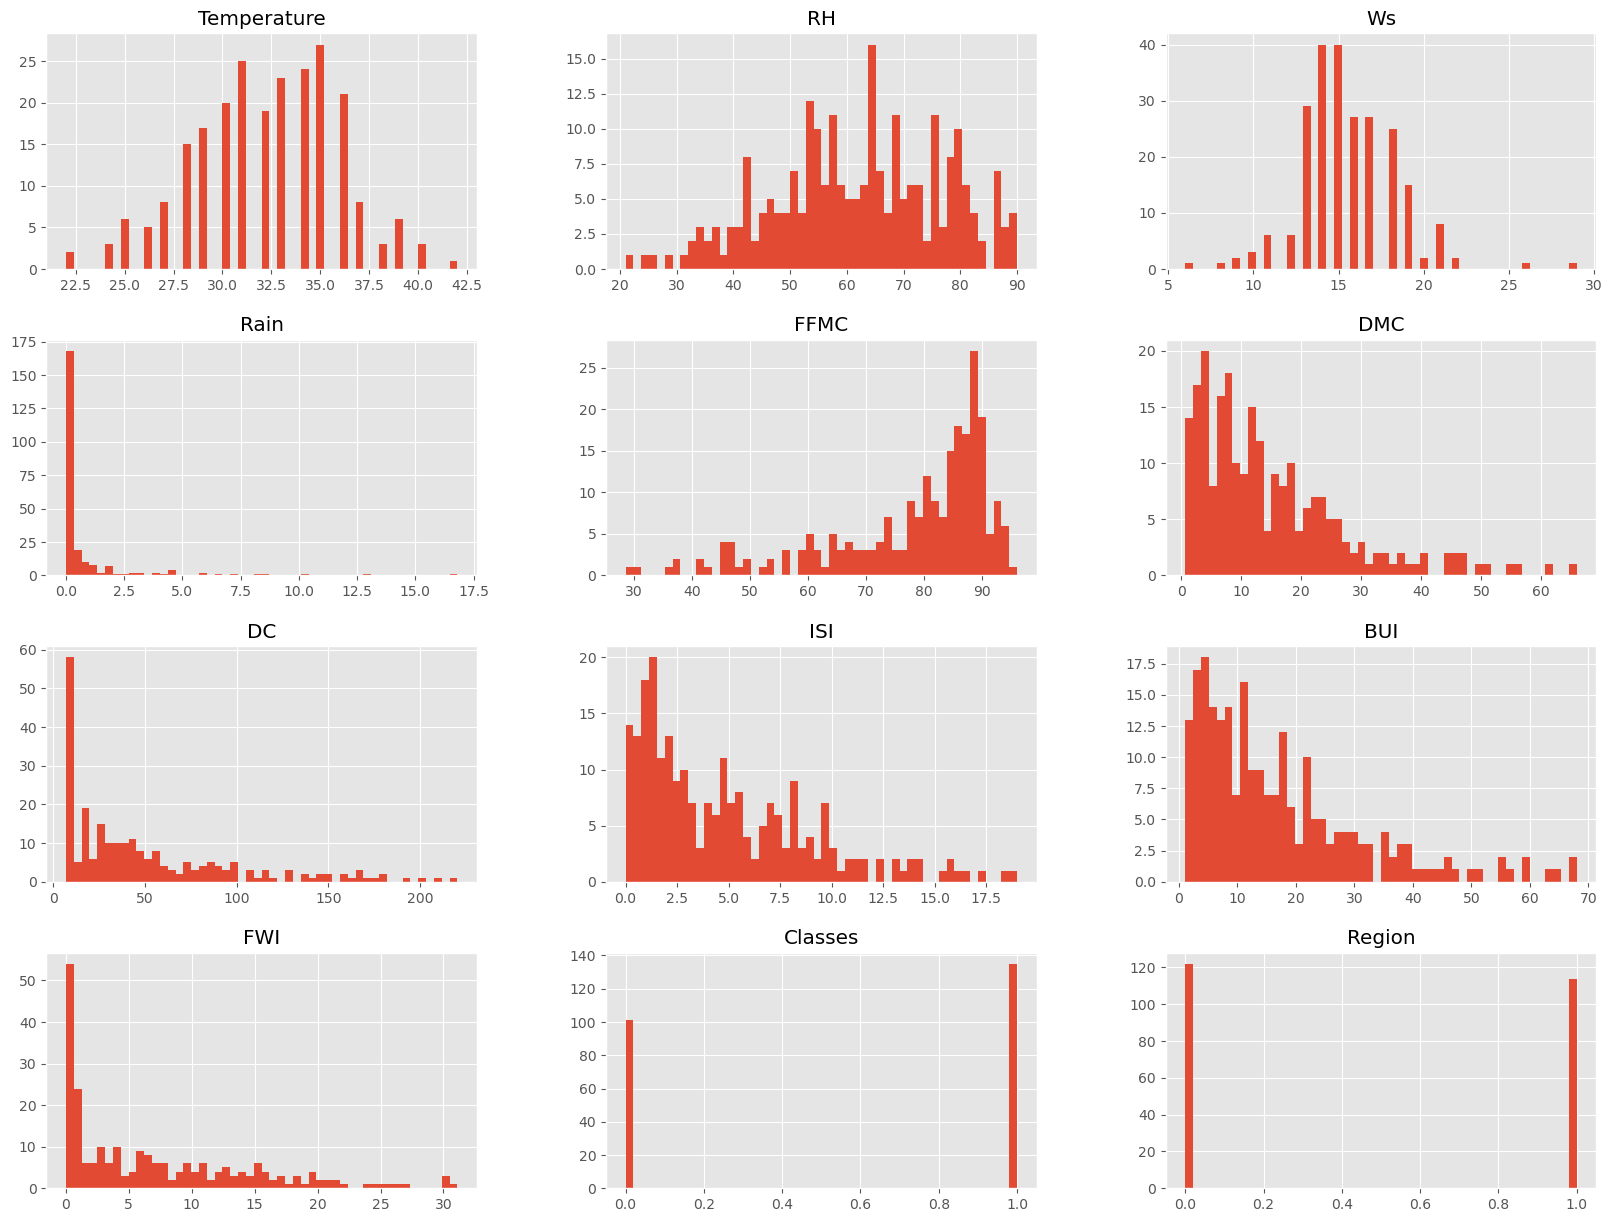

In [30]:
## plot density for all fetaures
plt.style.use('ggplot')
df_copy.hist(bins=50,figsize=(20,15))
plt.show()

In [31]:
#percentage of pi chart for classes
percentage=df_copy['Classes'].value_counts(normalize=True)*100

Text(0.5, 1.0, 'Percentage of fire and not fire classes')

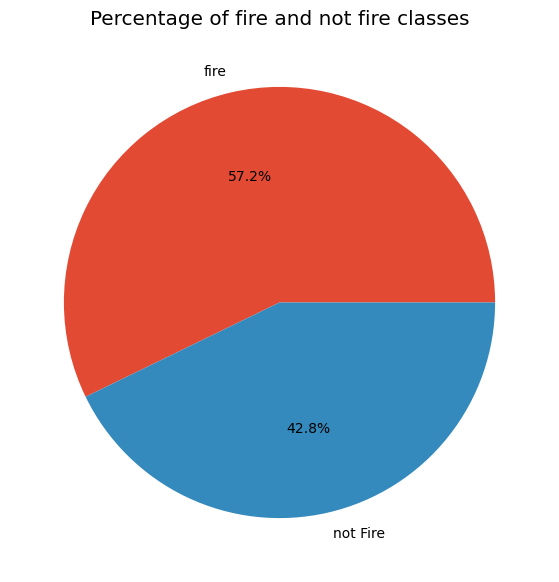

In [32]:
classlabels=["fire", "not Fire"]
plt.figure(figsize=(12,7))
plt.pie(percentage, labels=classlabels, autopct='%1.1f%%')
plt.title('Percentage of fire and not fire classes')

In [33]:
##correlation and multicollinearity
df_copy.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
Temperature,1.000000,-0.648352,-0.292130,-0.323387,0.679045,0.487646,0.376927,0.605240,0.461577,0.569130,0.511636,0.277695
RH,-0.648352,1.000000,0.257164,0.215677,-0.640460,-0.408403,-0.224587,-0.687916,-0.353062,-0.583270,-0.424521,-0.415878
Ws,-0.292130,0.257164,1.000000,0.179215,-0.188751,-0.018077,0.065198,-0.009034,0.014792,0.015365,-0.086424,-0.165314
Rain,-0.323387,0.215677,0.179215,1.000000,-0.541317,-0.287659,-0.297454,-0.345788,-0.299077,-0.324232,-0.378568,-0.044960
FFMC,0.679045,-0.640460,-0.188751,-0.541317,1.000000,0.601657,0.504381,0.739364,0.590053,0.692256,0.769835,0.247737
DMC,0.487646,-0.408403,-0.018077,-0.287659,0.601657,1.000000,0.873864,0.675253,0.981914,0.873752,0.582940,0.220096
DC,0.376927,-0.224587,0.065198,-0.297454,0.504381,0.873864,1.000000,0.501261,0.941065,0.735379,0.507769,-0.059129
ISI,0.605240,-0.687916,-0.009034,-0.345788,0.739364,0.675253,0.501261,1.000000,0.638287,0.921906,0.733895,0.289801
BUI,0.461577,-0.353062,0.014792,-0.299077,0.590053,0.981914,0.941065,0.638287,1.000000,0.855538,0.584135,0.115120
FWI,0.569130,-0.583270,0.015365,-0.324232,0.692256,0.873752,0.735379,0.921906,0.855538,1.000000,0.719000,0.224079


<Axes: >

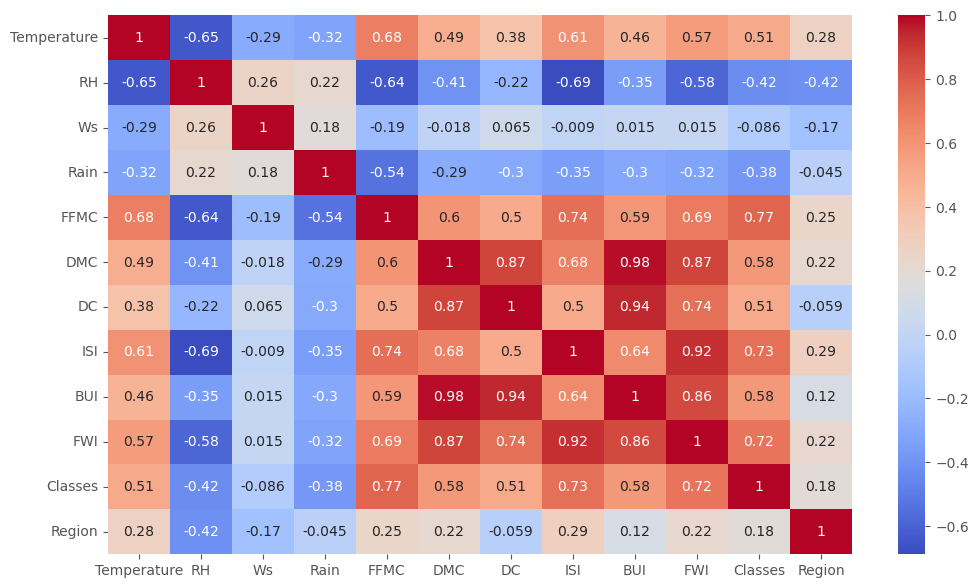

In [34]:
plt.figure(figsize=(12,7))
sns.heatmap(df_copy.corr(), annot=True, cmap='coolwarm')

<Axes: ylabel='FWI'>

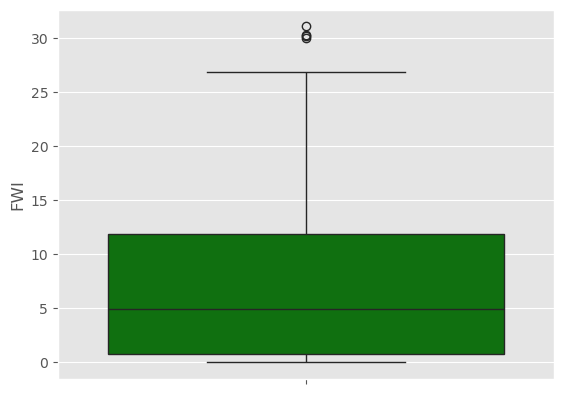

In [35]:
## box plot
sns.boxplot(df_copy['FWI'], color='green')

In [36]:
dataset.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [37]:
dataset['Classes']=np.where(dataset['Classes'].str.contains('not fire'), 'not fire', 'fire')

<Axes: xlabel='month', ylabel='count'>

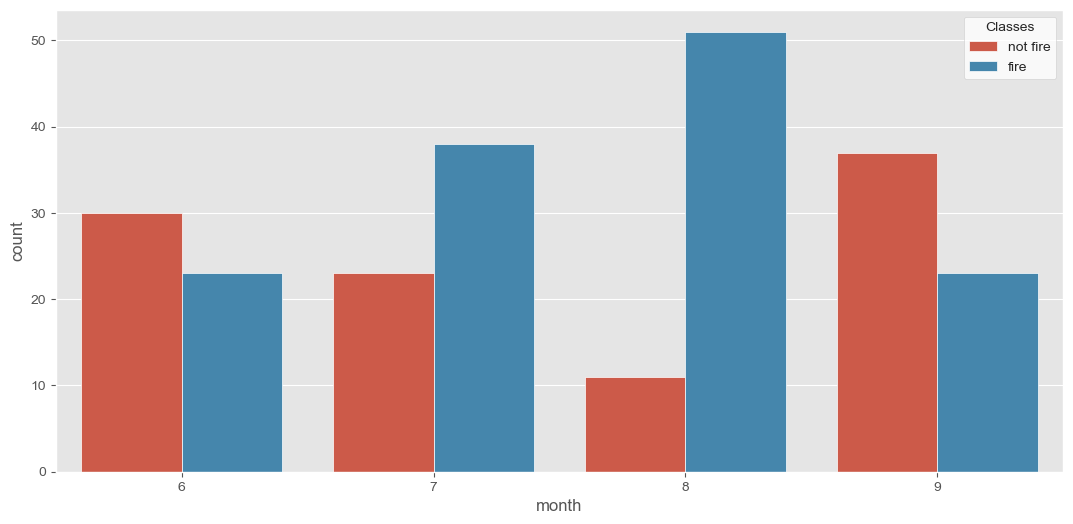

In [38]:
## montly fire analysis
dftemp=dataset.loc[dataset['Region']==1]
plt.subplots(figsize=(13,6))
sns.set_style('whitegrid')
sns.countplot(x='month', hue='Classes', data=dataset)

In [39]:
df=df_copy

In [40]:
df['Classes'].value_counts()

Classes
1    135
0    101
Name: count, dtype: int64

In [41]:
df_copy.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [42]:
## independent features and dependent fetaures
x=df.drop('FWI', axis=1)
y=df['FWI']

In [43]:
#train_test_split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.25, random_state=42)

In [44]:
x_train.shape, x_test.shape

((177, 11), (59, 11))

In [45]:
## Feature selection based on correlation
df_copy.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
Temperature,1.000000,-0.648352,-0.292130,-0.323387,0.679045,0.487646,0.376927,0.605240,0.461577,0.569130,0.511636,0.277695
RH,-0.648352,1.000000,0.257164,0.215677,-0.640460,-0.408403,-0.224587,-0.687916,-0.353062,-0.583270,-0.424521,-0.415878
Ws,-0.292130,0.257164,1.000000,0.179215,-0.188751,-0.018077,0.065198,-0.009034,0.014792,0.015365,-0.086424,-0.165314
Rain,-0.323387,0.215677,0.179215,1.000000,-0.541317,-0.287659,-0.297454,-0.345788,-0.299077,-0.324232,-0.378568,-0.044960
FFMC,0.679045,-0.640460,-0.188751,-0.541317,1.000000,0.601657,0.504381,0.739364,0.590053,0.692256,0.769835,0.247737
DMC,0.487646,-0.408403,-0.018077,-0.287659,0.601657,1.000000,0.873864,0.675253,0.981914,0.873752,0.582940,0.220096
DC,0.376927,-0.224587,0.065198,-0.297454,0.504381,0.873864,1.000000,0.501261,0.941065,0.735379,0.507769,-0.059129
ISI,0.605240,-0.687916,-0.009034,-0.345788,0.739364,0.675253,0.501261,1.000000,0.638287,0.921906,0.733895,0.289801
BUI,0.461577,-0.353062,0.014792,-0.299077,0.590053,0.981914,0.941065,0.638287,1.000000,0.855538,0.584135,0.115120
FWI,0.569130,-0.583270,0.015365,-0.324232,0.692256,0.873752,0.735379,0.921906,0.855538,1.000000,0.719000,0.224079


<Axes: >

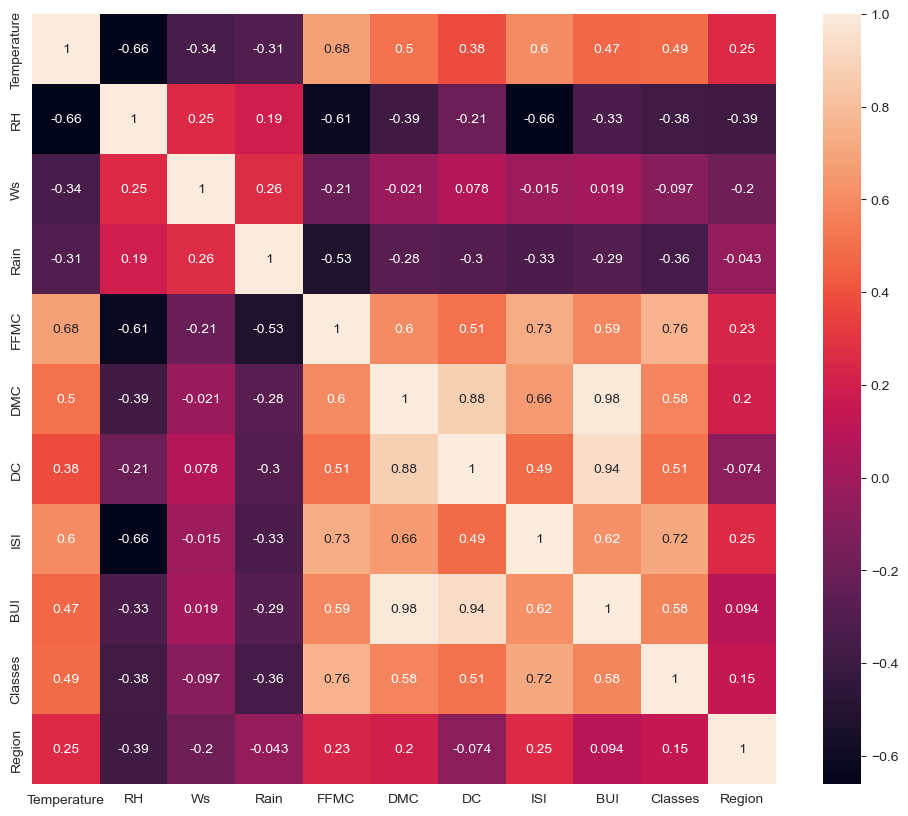

In [46]:
# check for multicollinearty
plt.figure(figsize=(12,10))
corr=x_train.corr()
sns.heatmap(corr, annot=True)

In [47]:
def correlation(dataset, thresold):
    col_corr=set()
    corr_matrix=dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j]) > thresold:
                colname=corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

In [48]:
corr_features=correlation(x_train, 0.85)

In [49]:
## dropping the fetaures when corr is more than 0.85
x_train.drop(corr_features, axis=1, inplace=True)
x_test.drop(corr_features, axis=1, inplace=True)


In [50]:
## feature scaling or standardizing

from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

<Axes: >

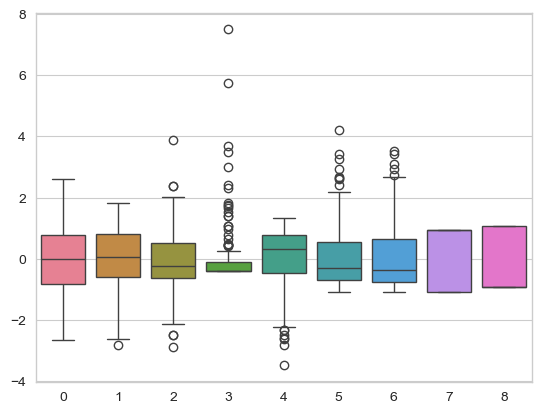

In [51]:
## Box plot to understand  Effect of Standard Scaler
sns.boxplot(data=x_train_scaled)

In [52]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
model=LinearRegression()
model.fit(x_train_scaled, y_train)
y_pred=model.predict(x_test)
print("r2_score: ", r2_score(y_test, y_pred))
print("mean_absolute_error: ", mean_absolute_error(y_test, y_pred))
print("mean_squared_error: ", mean_squared_error(y_test, y_pred))


r2_score:  -35.60275735447797
mean_absolute_error:  33.89236548295547
mean_squared_error:  2279.300702567731


C:\Users\ndhee\anaconda\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


## apply Lasso regression


In [53]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
model_lasso=Lasso()
model_lasso.fit(x_train_scaled, y_train)
y_pred=model_lasso.predict(x_test)
print("r2_score: ", r2_score(y_test, y_pred))
print("mean_absolute_error: ", mean_absolute_error(y_test, y_pred))
print("mean_squared_error: ", mean_squared_error(y_test, y_pred))


r2_score:  -94.95538258012033
mean_absolute_error:  65.90062176541426
mean_squared_error:  5975.264890891249


C:\Users\ndhee\anaconda\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but Lasso was fitted without feature names
  warnings.warn(


## ridge regression

In [54]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
model_Ridge=Ridge()
model_Ridge.fit(x_train_scaled, y_train)
y_pred=model_Ridge.predict(x_test)
print("r2_score: ", r2_score(y_test, y_pred))
print("mean_absolute_error: ", mean_absolute_error(y_test, y_pred))
print("mean_squared_error: ", mean_squared_error(y_test, y_pred))


r2_score:  -36.09204296343725
mean_absolute_error:  34.14270612200658
mean_squared_error:  2309.769145736009


C:\Users\ndhee\anaconda\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but Ridge was fitted without feature names
  warnings.warn(


## Elastic Net regression

In [55]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
model_elasticnet=ElasticNet()
model_elasticnet.fit(x_train_scaled, y_train)
y_pred=model_elasticnet.predict(x_test)
print("r2_score: ", r2_score(y_test, y_pred))
print("mean_absolute_error: ", mean_absolute_error(y_test, y_pred))
print("mean_squared_error: ", mean_squared_error(y_test, y_pred))


r2_score:  -83.47290704621614
mean_absolute_error:  63.35191409780009
mean_squared_error:  5260.236394590198


C:\Users\ndhee\anaconda\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but ElasticNet was fitted without feature names
  warnings.warn(


## Cross Validation Lasso

In [56]:
from sklearn.linear_model import LassoCV
lassocv=LassoCV(cv=5)
lassocv.fit(x_train_scaled, y_train)


LassoCV(cv=5)

In [57]:
lassocv.predict(x_test)

C:\Users\ndhee\anaconda\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but LassoCV was fitted without feature names
  warnings.warn(


array([ 42.06661743,  77.7497039 ,  -1.46932393,   4.92864107,
        12.69737975,  23.53692133,  16.21090164,  -8.46501052,
        33.92235393,  -8.17404391, 101.14631314,  63.31710154,
       151.68255668, -12.20282062,  94.10010964,  42.37096746,
       -10.42087185,  40.61664264,  79.90829081,  34.71157868,
        36.68124258,  22.26422524, -17.55431394,  39.34763542,
        80.34057831,  51.59081428, 137.13576301,  50.39428127,
       137.9555874 ,  -9.36908379,  15.79312488,  28.20416267,
        -5.52330383,  47.58430876,  81.79720859,  43.77238222,
       168.49862889, -10.71283929, -13.04433286, 106.8263433 ,
        87.29431374,  65.22565284,  42.71083876,  99.71234303,
       225.9614346 ,  35.57715869, 118.55820491,  -5.57345872,
        17.88066691,  -6.59383081,  48.22483532,  -5.02888917,
        21.48757214,  45.08312046,  10.19899941, -12.41304229,
       187.85231972,  51.80338685,   1.72186239])

In [58]:
lassocv.mse_path_

array([[56.24997737, 56.06216911, 37.69438944, 62.53082084, 46.50319408],
       [53.51356505, 51.33980307, 33.00472439, 57.69669869, 40.7487282 ],
       [47.21174739, 46.01479292, 28.91534273, 53.39319894, 35.46547578],
       [41.53923834, 40.63987025, 25.35880878, 49.55788158, 30.43879928],
       [36.58215403, 35.93439789, 22.26574249, 46.13598964, 26.15079034],
       [32.24889591, 31.81308203, 19.57574398, 43.07947883, 22.49952406],
       [28.45967839, 28.20201175, 17.23627212, 40.34617144, 19.39661242],
       [25.14501255, 25.03640158, 15.2017143 , 37.89901859, 16.76607151],
       [22.24435928, 22.25990706, 13.43231611, 35.7054568 , 14.54161229],
       [19.70500369, 19.82340966, 11.89352966, 33.65100147, 12.66606574],
       [17.48099215, 17.68392738, 10.55527064, 29.64621565, 11.08999747],
       [15.53228934, 15.80444579,  9.39148457, 26.154166  ,  9.77068075],
       [13.82400456, 14.15221244,  8.37940118, 23.10760506,  8.67102199],
       [12.32570998, 12.69881118,  7.4

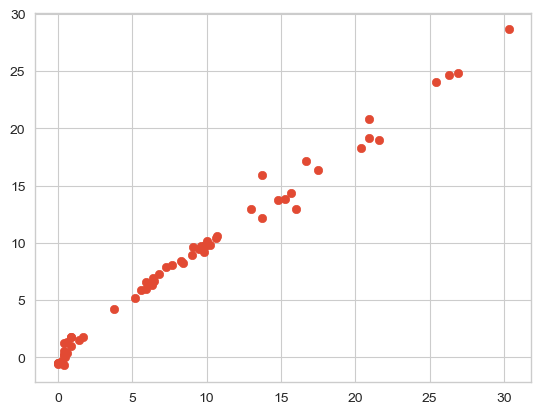

In [59]:
y_pred=lassocv.predict(x_test_scaled)
plt.scatter(y_test, y_pred)

In [60]:
print("r2_score: ", r2_score(y_test, y_pred))
print("mean_absolute_error: ", mean_absolute_error(y_test, y_pred))
print("mean_squared_error: ", mean_squared_error(y_test, y_pred))


r2_score:  0.9841347340840891
mean_absolute_error:  0.6929543596921459
mean_squared_error:  0.9879504813900426


r2_score:  0.9844028486120096
mean_absolute_error:  0.6849122433262496
mean_squared_error:  0.9712546454468846


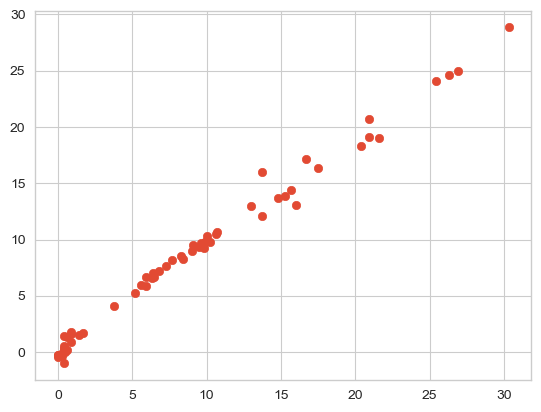

In [61]:
from sklearn.linear_model import RidgeCV
ridgecv=RidgeCV(cv=5)
ridgecv.fit(x_train_scaled, y_train)
y_pred=ridgecv.predict(x_test_scaled)
plt.scatter(y_test, y_pred)
print("r2_score: ", r2_score(y_test, y_pred))
print("mean_absolute_error: ", mean_absolute_error(y_test, y_pred))
print("mean_squared_error: ", mean_squared_error(y_test, y_pred))


In [62]:
ridgecv.alphas

(0.1, 1.0, 10.0)

r2_score:  0.9828728134211366
mean_absolute_error:  0.727684963202523
mean_squared_error:  1.0665319015217865


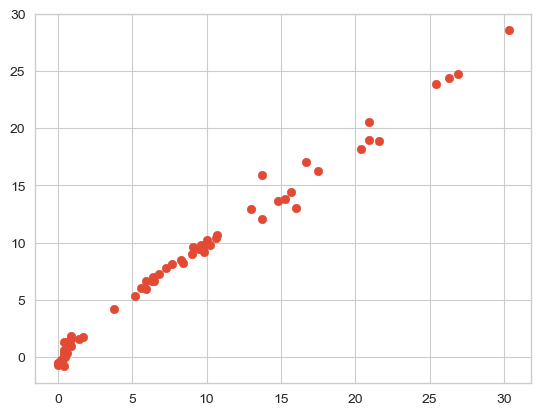

In [63]:
from sklearn.linear_model import ElasticNetCV
elasticnetcv=ElasticNetCV(cv=5)
elasticnetcv.fit(x_train_scaled, y_train)
y_pred=elasticnetcv.predict(x_test_scaled)
plt.scatter(y_test, y_pred)
print("r2_score: ", r2_score(y_test, y_pred))
print("mean_absolute_error: ", mean_absolute_error(y_test, y_pred))
print("mean_squared_error: ", mean_squared_error(y_test, y_pred))


In [64]:
##pickle the machine learning model and preprocesing the standardscaler


In [65]:
scaler

StandardScaler()

In [68]:
model_Ridge

Ridge()

In [69]:
import pickle
pickle.dump(scaler, open('scaler.pkl','wb'))
pickle.dump(scaler, open('model_ridge.pkl','wb'))